# Comparing your own structure files with BioPlex

The Figure 2F-H functions (see `TESTING BioPlex Figure 2F-H Reproduction.ipynb`) normally start from a PDB ID: the structure is downloaded from RCSB and its chains are matched to UniProt IDs through SIFTS. This notebook shows the same analysis for a **structure file on your own machine** -- an unpublished experimental model, or a prediction from AlphaFold3, Boltz or ColabFold/AF2-Multimer.

Every structure function in BioPlexPy accepts a path to a `.pdb`/`.ent`/`.cif`/`.mmcif` file anywhere it accepts a PDB ID. The one extra step is telling BioPlexPy **which protein each chain is**, since a local file has no SIFTS mapping. Either:

- pass the mapping yourself (`chain_to_uniprot={'A': 'P61158', ...}`), or
- give the complex's UniProt IDs and let `map_chains_to_uniprot()` match each chain by sequence.

Nothing about your structure leaves your machine: the only downloads are the BioPlex networks and, for sequence matching, the public UniProt sequences of the IDs you list.

The same analysis is available from the command line for batch use: `bioplexpy-structure --help`.

In [1]:
from bioplexpy import (PDB_to_interacting_chains_uniprot_maps,
                       compare_structure_contacts_to_BioPlex,
                       fetch_pdb_structure_file, getBioPlex,
                       map_chains_to_uniprot, render_figure2_panels_from_file)

bp_293t = getBioPlex('293T', '3.0')
bp_hct116 = getBioPlex('HCT116', '1.0')

## 1. A local structure file

As a stand-in for your own file, this downloads the TFIIH core complex (PDB `6NMI`, the paper's panel F) and then treats it purely as a local file. With your own structure, set `structure_file` to its path instead.

In [2]:
structure_file, _ = fetch_pdb_structure_file('6NMI', '.')
structure_file

'./pdb6nmi.ent'

### Matching chains to proteins by sequence

List the proteins you expect in the complex. Each protein chain is compared with each of them: first an exact substring match (the usual case for predictions, which are folded from the UniProt sequence), then a local alignment for experimental constructs with truncations, tags, mutations or a non-human ortholog. Unknown residues (`UNK`, e.g. backbone traced without a sequence assignment) are ignored.

The report shows the best match and the runner-up for each chain -- check it before trusting the mapping. A chain is only accepted if it passes `min_identity` (default 0.9) and `min_coverage` (default 0.5).

In [3]:
tfiih_uniprots = ['P19447', 'P18074', 'P32780', 'Q92759',   # ERCC3, ERCC2, GTF2H1, GTF2H4
                  'Q13888', 'Q13889', 'Q6ZYL4', 'P51948']   # GTF2H2, GTF2H3, GTF2H5, MNAT1

chain_map, match_report = map_chains_to_uniprot(structure_file, tfiih_uniprots)
match_report

,chain,chain_length,unknown_residues,uniprot,identity,chain_coverage,uniprot_coverage,method,accepted,runner_up,runner_up_identity,runner_up_chain_coverage
0,A,653,18,P19447,1.0,1.0,0.812,alignment,True,Q13888,0.348,0.280
1,B,760,27,P18074,1.0,1.0,0.964,alignment,True,Q92759,0.328,0.457
2,C,408,169,P32780,1.0,1.0,0.436,alignment,True,P51948,0.298,0.757
3,D,452,0,Q92759,1.0,1.0,0.978,exact,True,P18074,0.308,0.639
4,E,366,56,Q13888,1.0,1.0,0.785,alignment,True,P32780,0.267,0.713
5,F,263,0,Q13889,1.0,1.0,0.854,alignment,True,Q13888,0.279,0.764
6,G,66,0,Q6ZYL4,1.0,1.0,0.930,exact,True,P18074,0.348,0.697
7,H,210,0,P51948,1.0,1.0,0.680,exact,True,P18074,0.321,0.400


### Figure 2-style panels

`render_figure2_panels_from_file()` takes either `chain_to_uniprot` (as here) or `uniprot_IDs_list` (to do the sequence matching internally). The network panel is titled "Model" rather than "PDB", since a local file may be a prediction.

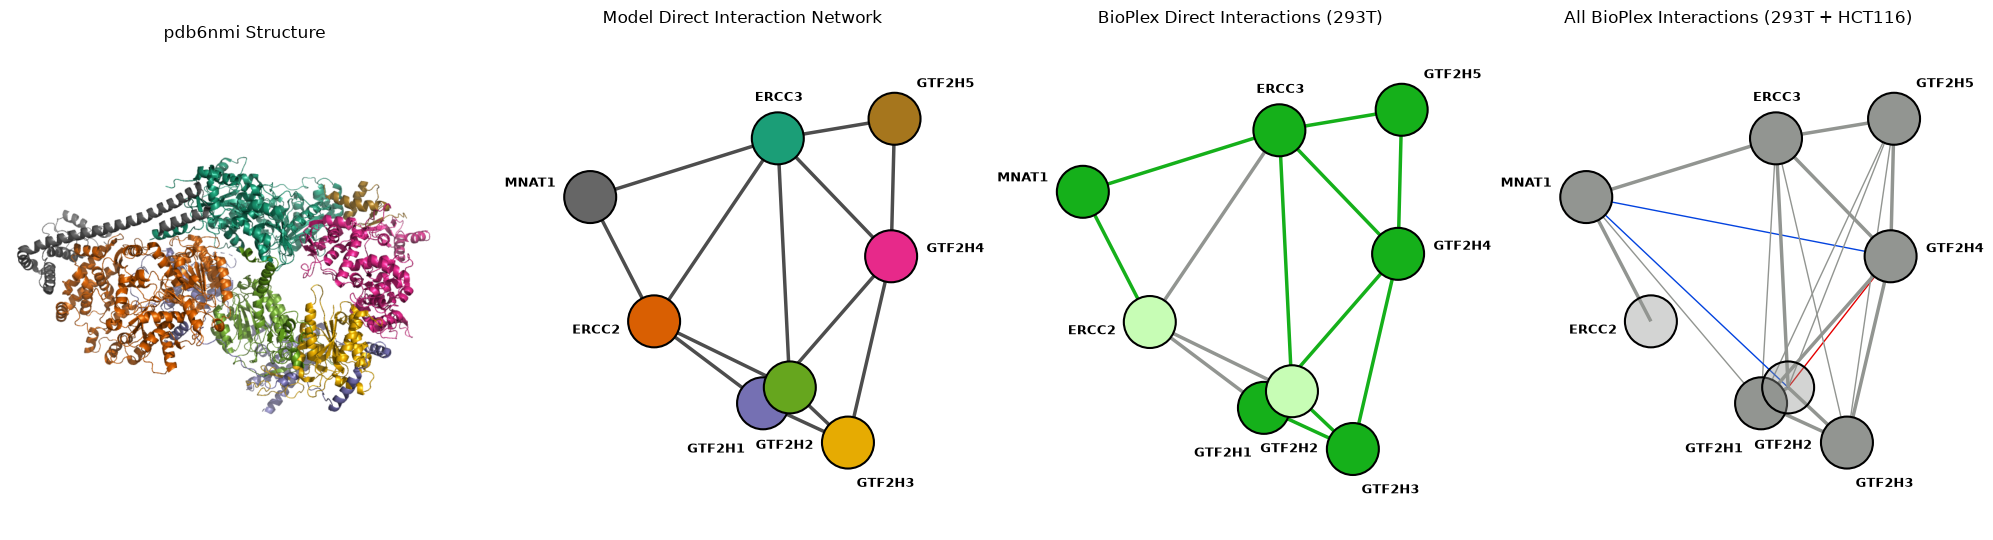

In [4]:
fig = render_figure2_panels_from_file(structure_file, bp_293t, bp_hct116,
                                      chain_to_uniprot=chain_map)

### The numbers behind the panels

`compare_structure_contacts_to_BioPlex()` lists every protein pair that is in direct contact in the structure, detected by BioPlex in either cell line, or both.

In [5]:
maps = PDB_to_interacting_chains_uniprot_maps(structure_file, None, 6,
                                              chain_to_uniprot=chain_map)
contacts = compare_structure_contacts_to_BioPlex(*maps, bp_293t, bp_hct116)
contacts

,UniprotA,UniprotB,SymbolA,SymbolB,structure_contact,bioplex_293T,bioplex_HCT116
0,P18074,P19447,ERCC2,ERCC3,True,False,False
1,P18074,P32780,ERCC2,GTF2H1,True,False,False
2,P18074,Q13888,ERCC2,GTF2H2,True,False,False
3,P18074,P51948,ERCC2,MNAT1,True,True,True
4,P19447,Q13888,ERCC3,GTF2H2,True,True,True
5,P19447,Q92759,ERCC3,GTF2H4,True,True,True
6,P19447,Q6ZYL4,ERCC3,GTF2H5,True,True,True
7,P19447,P51948,ERCC3,MNAT1,True,True,True
8,P32780,Q13888,GTF2H1,GTF2H2,True,True,True
9,P32780,Q13889,GTF2H1,GTF2H3,True,True,True


## 2. Predicted structures

Predictors place low-confidence regions (e.g. disordered loops) somewhere even when they don't know where they go, and those regions can touch other chains by chance. For predictions, pass `min_plddt` (0-100) to leave low-confidence atoms out of the contact search. pLDDT is read from the B-factor column, where AlphaFold, ColabFold and Boltz store it; values on a 0-1 scale are detected automatically. Don't use it for experimental structures, whose B-factor column holds real B-factors (you'll get a warning and the filter is skipped if the values can't be pLDDT).

Point `predictions_dir` at a folder of model files, e.g. an unzipped AlphaFold3 server job. Chains are matched by sequence separately for each file, since different tools can name the same chains differently.

In [6]:
import glob
import os

predictions_dir = 'my_predictions'   # folder of .cif/.pdb model files

if os.path.isdir(predictions_dir):
    for model_file in sorted(glob.glob(os.path.join(predictions_dir, '*.cif'))
                             + glob.glob(os.path.join(predictions_dir, '*.pdb'))):
        print(model_file)
        render_figure2_panels_from_file(model_file, bp_293t, bp_hct116,
                                        uniprot_IDs_list=tfiih_uniprots,
                                        min_plddt=70)
else:
    print(f"No '{predictions_dir}' folder -- set predictions_dir to your models.")

No 'my_predictions' folder -- set predictions_dir to your models.


## 3. From the command line

The same analysis runs without a notebook. For a directory of models:

```
bioplexpy-structure my_predictions/ \
    --uniprots P19447 P18074 P32780 Q92759 Q13888 Q13889 Q6ZYL4 P51948 \
    --min-plddt 70 --out-dir results/
```

For each structure this writes `<name>_figure.png`, `<name>_contacts.tsv` (the table above) and `<name>_chain_map.tsv` (the matching report). Use `--chain-map A=P19447 B=P18074 ...` or `--chain-map-file` to give the mapping explicitly, `--no-render` for the tables only, and `--interactive` for a py3Dmol HTML view instead of the static PyMOL image.